In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# update this path to where you uploaded your zip
zip_path = '/content/drive/MyDrive/maize_msv.zip'
extract_path = '/content/maize_msv'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# confirm folders exist
for split in ['maize_msv']:
    for cls in os.listdir(os.path.join(extract_path, split)):
        path = os.path.join(extract_path, split, cls)
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
maize_msv/valid: 6 images
maize_msv/train: 6 images
maize_msv/test: 6 images


In [4]:
%pip install -q tensorflow tensorflow-hub

In [5]:
%pip install -q tensorflow-hub

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [7]:
DATASET = "/content/maize_msv/maize_msv"

train_dir = os.path.join(DATASET, "train")
valid_dir = os.path.join(DATASET, "valid")
test_dir  = os.path.join(DATASET, "test")

In [8]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

SEED = 42

In [9]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9475 files belonging to 6 classes.
Found 2011 files belonging to 6 classes.
Found 1273 files belonging to 6 classes.


In [10]:
CLASS_NAMES = train_ds.class_names

CLASS_NAMES

['Common_Rust',
 'Gray_Leaf_Spot',
 'Healthy',
 'MSV',
 'Northern_Leaf_Blight',
 'Southern_Leaf_Blight']

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

valid_ds = valid_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

In [12]:
augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2)

])

In [13]:
base_model = MobileNetV3Small(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"

)

base_model.trainable = False

In [14]:
model = tf.keras.Sequential([

    augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(CLASS_NAMES),
        activation="softmax"
    )

])

In [15]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [16]:
callbacks = [

    EarlyStopping(

        patience=8,

        restore_best_weights=True

    ),

    ReduceLROnPlateau(

        patience=4,

        factor=0.2

    ),

    ModelCheckpoint(

        "best_model.keras",

        save_best_only=True

    )

]

In [17]:
history = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=15,

    callbacks=callbacks

)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.4502 - loss: 1.5664 - val_accuracy: 0.2665 - val_loss: 1.7650 - learning_rate: 0.0010
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.4558 - loss: 1.5183 - val_accuracy: 0.2665 - val_loss: 1.7541 - learning_rate: 0.0010
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.4555 - loss: 1.4838 - val_accuracy: 0.2665 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4587 - loss: 1.4569 - val_accuracy: 0.2665 - val_loss: 1.6732 - learning_rate: 0.0010
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.4582 - loss: 1.4364 - val_accuracy: 0.3580 - val_loss: 1.5437 - learning_rate: 0.0010
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.4631 - loss: 1.4143 - val_accuracy: 0.2675 - val_loss: 1.6530 - learning_rate: 0.0010
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.4648 - l

In [18]:
base_model.trainable = True

In [19]:
for layer in base_model.layers[:100]:
    layer.trainable = False

In [20]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [21]:
history_fine = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=15,

    callbacks=callbacks

)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.4287 - loss: 17.9047 - val_accuracy: 0.2665 - val_loss: 16.6245 - learning_rate: 1.0000e-05
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.4564 - loss: 3.2055 - val_accuracy: 0.2665 - val_loss: 30.2797 - learning_rate: 1.0000e-05
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.4993 - loss: 2.0657 - val_accuracy: 0.2665 - val_loss: 44.2688 - learning_rate: 1.0000e-05
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.5425 - loss: 1.6026 - val_accuracy: 0.2665 - val_loss: 53.4441 - learning_rate: 1.0000e-05
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.5614 - loss: 1.4268 - val_accuracy: 0.2665 - val_loss: 47.2928 - learning_rate: 2.0000e-06
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.5626 - loss: 1.3887 - val_accuracy: 0.2665 - val_loss: 37.4636 - learning_rate: 2.0000e-06
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 6

In [22]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

                      precision    recall  f1-score   support

         Common_Rust       0.00      0.00      0.00       191
      Gray_Leaf_Spot       0.00      0.00      0.00       165
             Healthy       0.00      0.00      0.00        96
                 MSV       0.00      0.00      0.00        96
Northern_Leaf_Blight       0.00      0.00      0.00       191
Southern_Leaf_Blight       0.42      1.00      0.59       534

            accuracy                           0.42      1273
           macro avg       0.07      0.17      0.10      1273
        weighted avg       0.18      0.42      0.25      1273



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV3Small
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. DATA AUGMENTATION - helps with small/imbalanced classes
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

# 2. BUILD MODEL
IMG_SIZE = (224, 224)
NUM_CLASSES = 6 # Common_Rust, Gray_Leaf_Spot, Healthy, MSV, Northern_Leaf_Blight, Southern_Leaf_Blight

base_model = MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Step 1: freeze for initial training

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 3. GET CLASS WEIGHTS TO BALANCE CLASSES
train_labels = []
for images, labels in train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# 4. TRAIN PHASE 1: Train only the top layers
print("\n--- Phase 1: Training top layers ---")
history1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    class_weight=class_weight_dict
)

# 5. TRAIN PHASE 2: Fine-tune the top of MobileNet
print("\n--- Phase 2: Fine-tuning ---")
base_model.trainable = True
# Freeze bottom layers, only train top 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), # much lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    class_weight=class_weight_dict
)

# 6. EVALUATE
print("\n--- Final Evaluation ---")
model.evaluate(valid_ds)



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,582 (3.60 MB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

Class weights: {0: np.float64(1.182896379525593), 1: np.float64(1.3743835219031042), 2: np.float64(2.353452558370591), 3: np.float64(2.353452558370591), 4: np.float64(1.182896379525593), 5: np.float64(0.36605625096584765)}

--- Phase 1: Training top layers ---
Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.8246 - loss: 0.5908 - val_accuracy: 0.9135 - val_loss: 0.2482
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9397 - loss: 0.2115 - val_accuracy: 0.9408 - val_loss: 0.1662
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9527 - loss: 0.1622 - val_accuracy: 0.9359 - val_loss: 0.1648
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9574 - loss: 0.1381 - val_accuracy: 0.9383 - val_loss: 0.1576
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9659 - loss: 0.1147 - val_accuracy: 0.9498 - val_loss: 0.1220
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.9666 - loss: 0.1068 -

[0.0979205071926117, 0.9582297205924988]

In [24]:
from sklearn.metrics import classification_report
import numpy as np

# Define class names manually - must match your folder names order
class_names = ['Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'MSV', 'Northern_Leaf_Blight', 'Southern_Leaf_Blight']

# Get predictions
y_pred = []
y_true = []
for images, labels in valid_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
                      precision    recall  f1-score   support

         Common_Rust     0.9974    0.9921    0.9947       381
      Gray_Leaf_Spot     0.9486    0.8445    0.8935       328
             Healthy     0.9947    0.9792    0.9869       192
                 MSV     0.9548    0.9896    0.9719       192
Northern_Leaf_Blight     0.8726    0.9686    0.9181       382
Southern_Leaf_Blight     0.9924    0.9776    0.9850       536

            accuracy                         0.9582      2011
           macro avg     0.9601    0.9586    0.9584      2011
        weighted avg     0.9601    0.9582    0.9581      2011



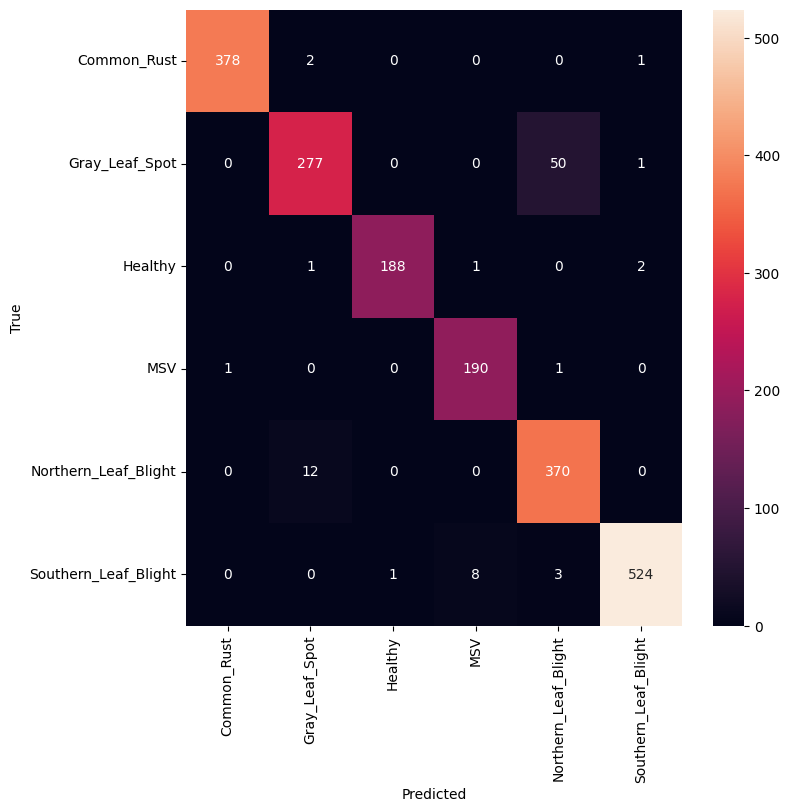

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

In [26]:
model.save("maizeguard_mobilenetv3.keras")

In [27]:
from google.colab import files

files.download(
    "maizeguard_mobilenetv3.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("maizeguard_mobilenetv3.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpp0guj49g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_364')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132232852457616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852456272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852456464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852456848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852455504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852457424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852455888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852456080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852457232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132232852458384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322328524

In [30]:
files.download("maizeguard_mobilenetv3.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/maizeguard_mobilenetv3.keras")
print("Saved to Googel Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Googel Drive


In [37]:

import tensorflow as tf
import numpy as np
from PIL import Image
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

model = tf.keras.models.load_model('app/models/best.keras')

CLASS_NAMES = [
    'Common_Rust',
    'Gray_Leaf_Spot', 
    'Healthy',
    'MSV',
    'Northern_Leaf_Blight',
    'Southern_Leaf_Blight',
]

# test with a real image — change this path to any maize image on your desktop
img_path = r'C:\Users\NKE\Desktop\test_leaf.jpg'

# test with /255 normalization
img = Image.open(img_path).convert('RGB').resize((224, 224))
arr = np.array(img, dtype=np.float32) / 255.0
arr = np.expand_dims(arr, axis=0)
pred = model.predict(arr, verbose=0)[0]
print('With /255 normalization:')
for i, p in enumerate(pred):
    print(f'  {CLASS_NAMES[i]}: {p:.4f}')
print(f'  Predicted: {CLASS_NAMES[np.argmax(pred)]}')

print()

# test without normalization
arr2 = np.array(img, dtype=np.float32)
arr2 = np.expand_dims(arr2, axis=0)
pred2 = model.predict(arr2, verbose=0)[0]
print('Without normalization (raw pixels):')
for i, p in enumerate(pred2):
    print(f'  {CLASS_NAMES[i]}: {p:.4f}')
print(f'  Predicted: {CLASS_NAMES[np.argmax(pred2)]}')

print()

# test with MobileNetV2 preprocessing (-1 to 1)
arr3 = np.array(img, dtype=np.float32)
arr3 = (arr3 / 127.5) - 1.0
arr3 = np.expand_dims(arr3, axis=0)
pred3 = model.predict(arr3, verbose=0)[0]
print('With MobileNetV2 preprocessing (-1 to 1):')
for i, p in enumerate(pred3):
    print(f'  {CLASS_NAMES[i]}: {p:.4f}')
print(f'  Predicted: {CLASS_NAMES[np.argmax(pred3)]}')
"

SyntaxError: unterminated string literal (detected at line 54) (420744436.py, line 54)